# 04 — S3Data SIM Telemetry Exploration

Analyses the raw SIM diagnostic records stored in `c:\S3Data` (mounted at `/home/jovyan/data` inside the container).

Structure: `data/sim/raw/sim_test_decoded/{year}/{month}/{year}_{month}_{day}.gz`

Each `.gz` file contains newline-delimited, comma-separated rows (no header).  
Each row is one periodic SIM report from a connected device.

## 1  Setup & Constants

In [2]:
import gzip
import glob
import os
from pathlib import Path
from datetime import date

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True

# ── paths ────────────────────────────────────────────────────────────────────
DATA_ROOT = Path('/home/jovyan/data/sim/raw/sim_test_decoded')

# ── column names (96 fields, positional) ─────────────────────────────────────
COLUMNS = [
    'event_id',          # 0  UUID
    'event_type',        # 1  PERIODICAL / etc.
    'device_time',       # 2  timestamp on the device
    'server_time',       # 3  arrival at server
    'batch_time',        # 4  batch-write timestamp
    'device_id',         # 5  device / modem identifier
    'sw_version',        # 6  firmware / SW version
    'report_interval',   # 7  reporting interval (s)
    'ip_address',        # 8  IP address
    'col_09',            # 9
    'col_10',            # 10
    'roaming',           # 11 0 = home, 1 = roaming
    'iccid',             # 12 SIM ICCID
    'imsi',              # 13 IMSI
    'imei',              # 14 IMEI
    'col_15',            # 15
    'col_16',            # 16
    'plmn_cell_id',      # 17 MCC-MNC-CellID
    'cell_id',           # 18 cell ID (numeric)
    'mcc',               # 19 Mobile Country Code
    'mnc',               # 20 Mobile Network Code
    'col_21',            # 21
    'tac',               # 22 Tracking Area Code
    'technology',        # 23 4G / 5G / 3G
    'cell_info_hex',     # 24 raw hex cell info
    'col_25',            # 25
    'col_26',            # 26
    'dl_bands',          # 27 downlink band(s)
    'rsrp',              # 28 serving cell RSRP (dBm)
    'rsrq',              # 29 serving cell RSRQ (dB)
    'pci',               # 30 serving cell PCI
    'n1_rsrp',           # 31 neighbour 1 RSRP
    'n1_rsrq',           # 32 neighbour 1 RSRQ
    'n1_pci',            # 33 neighbour 1 PCI
    'n2_rsrp',           # 34 neighbour 2 RSRP
    'n2_rsrq',           # 35 neighbour 2 RSRQ
    'n2_pci',            # 36 neighbour 2 PCI
    'n3_rsrp',           # 37 neighbour 3 RSRP
    'n3_rsrq',           # 38 neighbour 3 RSRQ
    'n3_pci',            # 39 neighbour 3 PCI
    'n4_rsrp',           # 40 neighbour 4 RSRP
    'n4_rsrq',           # 41 neighbour 4 RSRQ
] + [f'col_{i:02d}' for i in range(42, 82)] + [
    'metric_82',         # 82 numeric metric (quality / throughput)
    'metric_83',         # 83
    'metric_84',         # 84
    'metric_85',         # 85
    'metric_86',         # 86
    'metric_87',         # 87
    'col_88',            # 88
    'raw_payload',       # 89 hex payload
    'server_id',         # 90 server hostname
    'session_id',        # 91
    'col_92',            # 92
    'col_93',            # 93
    'col_94',            # 94
    'col_95',            # 95
]

assert len(COLUMNS) == 96, f'Expected 96 columns, got {len(COLUMNS)}'
print('Column map ready:', len(COLUMNS), 'fields')

Column map ready: 96 fields


## 2  Dataset Inventory

Scan the directory tree to understand what dates are available and how many records exist.

In [3]:
all_files = sorted(DATA_ROOT.rglob('*.gz'))

inventory = []
for fp in all_files:
    size_mb = fp.stat().st_size / 1_048_576
    # derive date from path  e.g. …/2024/04/2024_04_11.gz
    stem = fp.stem            # '2024_04_11'
    parts = stem.split('_')   # ['2024', '04', '11']
    try:
        d = date(int(parts[0]), int(parts[1]), int(parts[2]))
    except Exception:
        d = None
    inventory.append({'date': d, 'path': fp, 'size_mb': round(size_mb, 2)})

inv_df = pd.DataFrame(inventory)
non_empty = inv_df[inv_df.size_mb > 0.01]

print(f'Total files : {len(inv_df):,}')
print(f'Non-empty   : {len(non_empty):,}')
print(f'Date range  : {non_empty.date.min()}  →  {non_empty.date.max()}')
print(f'Total size  : {non_empty.size_mb.sum():.0f} MB ({non_empty.size_mb.sum()/1024:.1f} GB)')
non_empty.tail(10)

Total files : 464
Non-empty   : 245
Date range  : 2024-05-09  →  2025-07-08
Total size  : 70514 MB (68.9 GB)


,date,path,size_mb
454,2025-06-29,/home/jovyan/data/sim/raw/sim_test_decoded/202...,572.24
455,2025-06-30,/home/jovyan/data/sim/raw/sim_test_decoded/202...,571.44
456,2025-07-01,/home/jovyan/data/sim/raw/sim_test_decoded/202...,572.14
457,2025-07-02,/home/jovyan/data/sim/raw/sim_test_decoded/202...,571.24
458,2025-07-03,/home/jovyan/data/sim/raw/sim_test_decoded/202...,567.45
459,2025-07-04,/home/jovyan/data/sim/raw/sim_test_decoded/202...,566.14
460,2025-07-05,/home/jovyan/data/sim/raw/sim_test_decoded/202...,567.20
461,2025-07-06,/home/jovyan/data/sim/raw/sim_test_decoded/202...,566.24
462,2025-07-07,/home/jovyan/data/sim/raw/sim_test_decoded/202...,566.98
463,2025-07-08,/home/jovyan/data/sim/raw/sim_test_decoded/202...,567.52


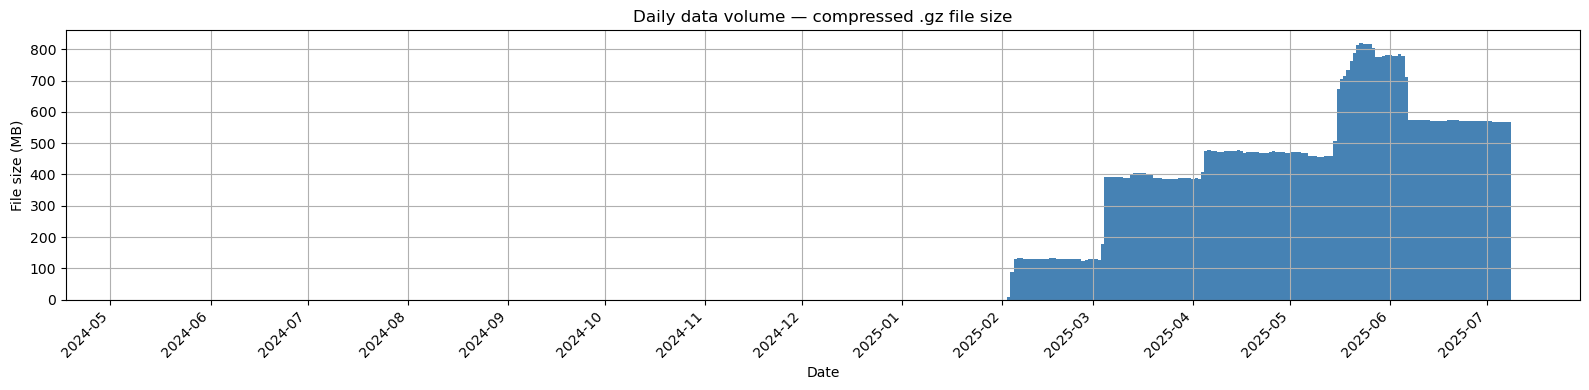

In [4]:
# ── daily file size over time ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(non_empty['date'], non_empty['size_mb'], width=1, color='steelblue')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('Date')
ax.set_ylabel('File size (MB)')
ax.set_title('Daily data volume — compressed .gz file size')
plt.tight_layout()

## 3  Load a Sample Window

Loading a single day into memory is fast; adjust `SAMPLE_DAYS` or filter by date range for larger analyses.

In [1]:
def load_day(fp: Path) -> pd.DataFrame:
    """Read one .gz CSV into a DataFrame with named columns."""
    try:
        df = pd.read_csv(
            fp,
            names=COLUMNS,
            header=None,
            dtype=str,          # read everything as str first for safety
            compression='gzip',
            on_bad_lines='skip',
        )
        df['_source_file'] = fp.name
        return df
    except Exception as e:
        print(f'  SKIP {fp.name}: {e}')
        return pd.DataFrame()


def cast_types(df: pd.DataFrame) -> pd.DataFrame:
    """Convert columns to sensible dtypes."""
    ts_cols = ['device_time', 'server_time', 'batch_time']
    for c in ts_cols:
        df[c] = pd.to_datetime(df[c], errors='coerce')

    num_cols = [
        'roaming', 'report_interval',
        'cell_id', 'mcc', 'mnc', 'tac',
        'rsrp', 'rsrq', 'pci',
        'n1_rsrp', 'n1_rsrq', 'n1_pci',
        'n2_rsrp', 'n2_rsrq', 'n2_pci',
        'n3_rsrp', 'n3_rsrq', 'n3_pci',
        'n4_rsrp', 'n4_rsrq',
        'metric_82', 'metric_83', 'metric_84',
        'metric_85', 'metric_86', 'metric_87',
    ]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    # strip whitespace from string cols
    for c in ['event_type', 'technology', 'device_id', 'iccid', 'imei']:
        df[c] = df[c].str.strip()

    return df

NameError: name 'Path' is not defined

In [ ]:
# ── configure what to load ─────────────────────────────────────────────────
# Change these to explore a different time window.
LOAD_START = '2025-05-20'
LOAD_END   = '2025-05-23'   # inclusive

files_to_load = non_empty[
    (non_empty['date'] >= pd.to_datetime(LOAD_START).date()) &
    (non_empty['date'] <= pd.to_datetime(LOAD_END).date())
]['path'].tolist()

print(f'Loading {len(files_to_load)} day(s): {LOAD_START} → {LOAD_END}')

chunks = []
for fp in files_to_load:
    print(f'  reading {fp.name} …', end=' ')
    chunk = load_day(fp)
    chunk = cast_types(chunk)
    print(f'{len(chunk):,} rows')
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
print(f'\nTotal loaded: {len(df):,} rows  |  {df.memory_usage(deep=True).sum() / 1_048_576:.0f} MB')
df.head(3)

Loading 4 day(s): 2025-05-20 → 2025-05-23
  reading 2025_05_20.gz … 4,188,970 rows
  reading 2025_05_21.gz … 4,370,235 rows
  reading 2025_05_22.gz … 4,481,029 rows
  reading 2025_05_23.gz … 

## 4  Data Quality Overview

In [ ]:
# ── null / blank rates for the key columns ────────────────────────────────
key_cols = [
    'event_type', 'device_time', 'server_time',
    'device_id', 'sw_version', 'roaming',
    'iccid', 'imei',
    'cell_id', 'mcc', 'mnc', 'tac', 'technology',
    'rsrp', 'rsrq', 'pci',
]

null_pct = (df[key_cols].isna().mean() * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 4))
null_pct.plot(kind='bar', ax=ax, color='salmon', edgecolor='white')
ax.set_ylabel('% null / unparseable')
ax.set_title('Null rates — key columns')
ax.set_ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [ ]:
print('Shape:      ', df.shape)
print('Event types:', df['event_type'].value_counts().to_dict())
print('Technologies:', df['technology'].value_counts().to_dict())
print('Roaming     0=home / 1=roam:')
print(df['roaming'].value_counts().to_dict())
print('Unique devices (device_id):', df['device_id'].nunique())
print('Unique SIMs  (iccid)      :', df['iccid'].nunique())
print('Unique cells (cell_id)    :', df['cell_id'].nunique())

## 5  Signal Quality — RSRP & RSRQ

| Metric | Good   | Fair          | Poor    |
|--------|--------|---------------|---------|
| RSRP   | > −80 dBm | −80 to −100 dBm | < −100 dBm |
| RSRQ   | > −10 dB  | −10 to −15 dB   | < −15 dB   |

In [ ]:
rsrp_clean = df['rsrp'].dropna()
rsrq_clean = df['rsrq'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# RSRP
axes[0].hist(rsrp_clean, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(-80,  color='green',  linestyle='--', label='Good (−80)')
axes[0].axvline(-100, color='orange', linestyle='--', label='Fair (−100)')
axes[0].set_title('RSRP Distribution (serving cell, dBm)')
axes[0].set_xlabel('RSRP (dBm)')
axes[0].legend()

# RSRQ
axes[1].hist(rsrq_clean, bins=40, color='coral', edgecolor='white')
axes[1].axvline(-10, color='green',  linestyle='--', label='Good (−10)')
axes[1].axvline(-15, color='orange', linestyle='--', label='Fair (−15)')
axes[1].set_title('RSRQ Distribution (serving cell, dB)')
axes[1].set_xlabel('RSRQ (dB)')
axes[1].legend()

plt.tight_layout()

In [ ]:
# ── quality bucket breakdown ───────────────────────────────────────────────
def rsrp_bucket(v):
    if pd.isna(v):    return 'unknown'
    if v > -80:       return 'good (>-80)'
    if v > -100:      return 'fair (-100 to -80)'
    return                   'poor (<-100)'

df['rsrp_quality'] = df['rsrp'].map(rsrp_bucket)
quality_counts = df['rsrp_quality'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
colors = {'good (>-80)': 'green', 'fair (-100 to -80)': 'orange', 'poor (<-100)': 'red', 'unknown': 'grey'}
quality_counts.plot(kind='bar', ax=ax,
                    color=[colors.get(k, 'grey') for k in quality_counts.index],
                    edgecolor='white')
ax.set_title('RSRP quality buckets')
ax.set_xlabel('')
ax.set_ylabel('Record count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

print(quality_counts.to_string())
print(f'\nGood+Fair share: {100*(quality_counts.get("good (>-80)",0)+quality_counts.get("fair (-100 to -80)",0))/len(df):.1f}%')

## 6  Technology Breakdown (4G / 5G / other)

In [ ]:
tech_counts = df['technology'].fillna('unknown').value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

tech_counts.plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Records by technology')
axes[0].set_xlabel('')
axes[0].set_ylabel('Record count')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

axes[1].pie(tech_counts, labels=tech_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Technology share')

plt.tight_layout()

In [ ]:
# ── RSRP by technology ─────────────────────────────────────────────────────
tech_rsrp = (
    df.dropna(subset=['rsrp', 'technology'])
    .groupby('technology')['rsrp']
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
    .round(1)
)
display(tech_rsrp)

## 7  Network Operators (MCC / MNC)

In [ ]:
df['operator'] = df['mcc'].astype(str) + '-' + df['mnc'].astype(str)

op_counts = df['operator'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(14, 4))
op_counts.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
ax.set_title('Top 15 operators (MCC-MNC)')
ax.set_xlabel('Operator (MCC-MNC)')
ax.set_ylabel('Record count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

## 8  Roaming Analysis

In [ ]:
roam_label = df['roaming'].map({0.0: 'Home', 1.0: 'Roaming'}).fillna('unknown')
roam_counts = roam_label.value_counts()
print(roam_counts.to_string())

# RSRP comparison: home vs roaming
fig, ax = plt.subplots(figsize=(10, 4))
for label, grp in df.assign(roaming_label=roam_label).groupby('roaming_label'):
    rsrp = grp['rsrp'].dropna()
    if len(rsrp) > 0:
        ax.hist(rsrp, bins=50, alpha=0.6, label=label, edgecolor='white')
ax.set_title('RSRP distribution: Home vs Roaming')
ax.set_xlabel('RSRP (dBm)')
ax.legend()
plt.tight_layout()

## 9  Temporal Trends

Hour-of-day and daily rolling statistics.

In [ ]:
df_ts = df.dropna(subset=['server_time', 'rsrp']).copy()
df_ts['hour'] = df_ts['server_time'].dt.hour
df_ts['date'] = df_ts['server_time'].dt.date

# ── hourly median RSRP ─────────────────────────────────────────────────────
hourly = df_ts.groupby('hour')['rsrp'].median()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(hourly.index, hourly.values, marker='o', color='steelblue')
axes[0].set_title('Median RSRP by hour of day')
axes[0].set_xlabel('Hour (UTC)')
axes[0].set_ylabel('Median RSRP (dBm)')
axes[0].set_xticks(range(0, 24))

# ── record volume by hour ──────────────────────────────────────────────────
hourly_vol = df_ts.groupby('hour').size()
axes[1].bar(hourly_vol.index, hourly_vol.values, color='teal', edgecolor='white')
axes[1].set_title('Record volume by hour of day')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_ylabel('Record count')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()

In [ ]:
# ── daily stats ────────────────────────────────────────────────────────────
daily = (
    df_ts.groupby('date')
    .agg(
        records   = ('rsrp', 'count'),
        rsrp_med  = ('rsrp', 'median'),
        rsrp_p10  = ('rsrp', lambda x: x.quantile(0.10)),
        rsrp_p90  = ('rsrp', lambda x: x.quantile(0.90)),
        unique_devices = ('device_id', 'nunique'),
    )
    .reset_index()
)
daily['date'] = pd.to_datetime(daily['date'])

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# RSRP trend with percentile band
axes[0].fill_between(daily['date'], daily['rsrp_p10'], daily['rsrp_p90'],
                     alpha=0.2, color='steelblue', label='P10-P90')
axes[0].plot(daily['date'], daily['rsrp_med'], color='steelblue', label='Median RSRP')
axes[0].set_ylabel('RSRP (dBm)')
axes[0].set_title('Daily RSRP trend')
axes[0].legend()

# Record volume
axes[1].bar(daily['date'], daily['records'], width=0.8, color='teal')
axes[1].set_ylabel('Records / day')
axes[1].set_title('Daily record volume')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=30, ha='right')

plt.tight_layout()

## 10  Top Cells & Neighbour Signal Delta

In [ ]:
top_cells = (
    df.dropna(subset=['cell_id', 'rsrp'])
    .groupby('cell_id')
    .agg(
        records   = ('rsrp', 'count'),
        rsrp_mean = ('rsrp', 'mean'),
        rsrp_std  = ('rsrp', 'std'),
        rsrq_mean = ('rsrq', 'mean'),
    )
    .sort_values('records', ascending=False)
    .head(20)
    .round(1)
)
display(top_cells)

In [ ]:
# ── serving vs best-neighbour RSRP delta ──────────────────────────────────
df_nb = df.dropna(subset=['rsrp', 'n1_rsrp']).copy()
df_nb['best_nb_rsrp'] = df_nb[['n1_rsrp','n2_rsrp','n3_rsrp','n4_rsrp']].max(axis=1)
df_nb['rsrp_delta'] = df_nb['best_nb_rsrp'] - df_nb['rsrp']

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_nb['rsrp_delta'].clip(-30, 30), bins=60, color='darkorange', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', label='No difference')
ax.set_title('Best-neighbour RSRP − Serving RSRP (dBm)\n'
             'Positive = a neighbour is stronger than the serving cell')
ax.set_xlabel('RSRP delta (dBm)')
ax.legend()
plt.tight_layout()

pct_better_nb = 100 * (df_nb['rsrp_delta'] > 3).mean()
print(f'Rows where a neighbour is >3 dBm stronger: {pct_better_nb:.1f}%  '
      f'(potential handover candidates)')

## 11  Per-Device Summary

In [ ]:
per_device = (
    df.dropna(subset=['device_id', 'rsrp'])
    .groupby('device_id')
    .agg(
        records      = ('rsrp', 'count'),
        rsrp_mean    = ('rsrp', 'mean'),
        rsrp_min     = ('rsrp', 'min'),
        poor_pct     = ('rsrp', lambda x: 100*(x < -100).mean()),
        sw_version   = ('sw_version', 'first'),
        iccid        = ('iccid', 'first'),
    )
    .sort_values('records', ascending=False)
    .round(1)
)

print(f'Unique devices: {len(per_device)}')
display(per_device.head(15))

In [ ]:
# ── histogram: per-device mean RSRP ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(per_device['rsrp_mean'].dropna(), bins=40, color='steelblue', edgecolor='white')
ax.set_title('Distribution of per-device mean RSRP')
ax.set_xlabel('Mean RSRP (dBm)')
ax.set_ylabel('Number of devices')
plt.tight_layout()

## 12  Software Version Breakdown

In [ ]:
sw_counts = df['sw_version'].fillna('unknown').value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 4))
sw_counts.plot(kind='bar', ax=ax, color='slategray', edgecolor='white')
ax.set_title('Records by firmware/SW version')
ax.set_xlabel('SW version')
ax.set_ylabel('Record count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

## 13  Scaling Up — Loading the Full Dataset

For production analysis across the entire archive use chunked loading or a Dask/Spark approach.  
The cell below shows a lightweight monthly aggregation using a streaming approach.

In [ ]:
# ── streaming monthly stats (no large in-memory DataFrame) ────────────────
# Adjust the date filter to cover your period of interest.
# Estimated runtime: ~2–5 min for the full archive depending on disk speed.

AGGREGATE_START = '2025-01-01'
AGGREGATE_END   = '2025-03-31'

files_all = non_empty[
    (non_empty['date'] >= pd.to_datetime(AGGREGATE_START).date()) &
    (non_empty['date'] <= pd.to_datetime(AGGREGATE_END).date())
]['path'].tolist()

monthly_agg = {}

for fp in files_all:
    chunk = load_day(fp)
    if chunk.empty:
        continue
    chunk = cast_types(chunk)
    chunk['ym'] = chunk['server_time'].dt.to_period('M').astype(str)

    for ym, grp in chunk.groupby('ym'):
        rsrp = grp['rsrp'].dropna()
        if ym not in monthly_agg:
            monthly_agg[ym] = {'records': 0, 'rsrp_sum': 0.0, 'rsrp_count': 0, 'devices': set()}
        monthly_agg[ym]['records']    += len(grp)
        monthly_agg[ym]['rsrp_sum']   += rsrp.sum()
        monthly_agg[ym]['rsrp_count'] += len(rsrp)
        monthly_agg[ym]['devices']    |= set(grp['device_id'].dropna().unique())

monthly_df = pd.DataFrame([
    {
        'month': ym,
        'records': v['records'],
        'mean_rsrp': round(v['rsrp_sum'] / v['rsrp_count'], 1) if v['rsrp_count'] else None,
        'unique_devices': len(v['devices']),
    }
    for ym, v in sorted(monthly_agg.items())
])

display(monthly_df)

In [ ]:
if not monthly_df.empty:
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    axes[0].bar(monthly_df['month'], monthly_df['records'], color='steelblue')
    axes[0].set_title('Monthly record volume')
    axes[0].set_ylabel('Records')

    axes[1].plot(monthly_df['month'], monthly_df['mean_rsrp'], marker='o', color='coral')
    axes[1].set_title('Monthly mean RSRP')
    axes[1].set_ylabel('Mean RSRP (dBm)')
    axes[1].set_xlabel('Month')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()